In [1]:
import pandas as pd
import ast

valid_purchase_lines = pd.read_csv("../data/processed/valid_purchase_lines.csv")
cancellation_lines = pd.read_csv("../data/processed/cancellation_lines.csv")
stock_adjustment_lines = pd.read_csv("../data/processed/stock_adjustment_lines.csv")

print("valid_purchase_lines:", valid_purchase_lines.shape)
print("cancellation_lines:", cancellation_lines.shape)
print("stock_adjustment_lines:", stock_adjustment_lines.shape)

valid_purchase_lines: (349203, 15)
cancellation_lines: (9251, 15)
stock_adjustment_lines: (1336, 16)


In [2]:
invoice_features = valid_purchase_lines.groupby('InvoiceNo').agg(
    CustomerID=('CustomerID', 'first'),
    InvoiceDate=('InvoiceDate', 'first'),
    InvoiceValue=('Revenue', 'sum'),
    TotalQuantity=('Quantity', 'sum'),
    ProductDiversity=('StockCode', 'nunique'),
    LineCount=('StockCode', 'count')
).reset_index()

print(invoice_features.shape)
invoice_features.describe()

(16646, 7)


,InvoiceNo,CustomerID,InvoiceValue,TotalQuantity,ProductDiversity,LineCount
count,16646.000000,16646.000000,16646.000000,16646.000000,16646.000000,16646.000000
mean,559465.892887,15507.717890,437.644157,254.794245,20.691758,20.978193
std,13065.694100,1626.191207,1663.377636,946.837079,23.946498,24.527801
min,536365.000000,12346.000000,0.380000,1.000000,1.000000,1.000000
25%,548329.250000,14098.250000,152.262500,72.000000,6.000000,6.000000
50%,559676.500000,15498.000000,298.280000,149.000000,15.000000,15.000000
75%,570823.250000,16923.000000,442.347500,276.000000,27.000000,27.000000
max,581586.000000,18287.000000,168469.600000,80995.000000,541.000000,542.000000


In [3]:
import numpy as np

def robust_zscore(series):
    median = series.median()
    mad = (series - median).abs().median()  # median absolute deviation
    # 0.6745 scales MAD to be comparable to standard deviation for normal data
    return 0.6745 * (series - median) / mad

for col in ['InvoiceValue', 'TotalQuantity', 'ProductDiversity']:
    invoice_features[f'{col}_robust_z'] = robust_zscore(invoice_features[col])

# IQR-based flag as a second, independent method (for consistency-check per Section 23 evaluation)
def iqr_flag(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - k*iqr) | (series > q3 + k*iqr)

for col in ['InvoiceValue', 'TotalQuantity', 'ProductDiversity']:
    invoice_features[f'{col}_iqr_flag'] = iqr_flag(invoice_features[col])

# Combine: flagged if robust z-score exceeds 3.5 in magnitude (common robust threshold) OR IQR flags it
invoice_features['AnomalyFlag_N0'] = (
    (invoice_features[['InvoiceValue_robust_z','TotalQuantity_robust_z','ProductDiversity_robust_z']].abs() > 3.5).any(axis=1)
    | invoice_features[['InvoiceValue_iqr_flag','TotalQuantity_iqr_flag','ProductDiversity_iqr_flag']].any(axis=1)
)

print("Invoices flagged as N0 anomalies:", invoice_features['AnomalyFlag_N0'].sum(), 
      f"({invoice_features['AnomalyFlag_N0'].mean()*100:.2f}%)")

Invoices flagged as N0 anomalies: 2241 (13.46%)


In [4]:
# Break down flagging by method and by variable
print("=== Flags by individual criterion ===")
for col in ['InvoiceValue', 'TotalQuantity', 'ProductDiversity']:
    z_flag = invoice_features[f'{col}_robust_z'].abs() > 3.5
    iqr_flag_col = invoice_features[f'{col}_iqr_flag']
    print(f"{col}: robust-z flags {z_flag.sum()} ({z_flag.mean()*100:.2f}%), "
          f"IQR flags {iqr_flag_col.sum()} ({iqr_flag_col.mean()*100:.2f}%), "
          f"overlap {(z_flag & iqr_flag_col).sum()}")

print("\n=== Agreement between the two combined methods ===")
any_z = (invoice_features[['InvoiceValue_robust_z','TotalQuantity_robust_z','ProductDiversity_robust_z']].abs() > 3.5).any(axis=1)
any_iqr = invoice_features[['InvoiceValue_iqr_flag','TotalQuantity_iqr_flag','ProductDiversity_iqr_flag']].any(axis=1)
print("Flagged by robust-z only:", (any_z & ~any_iqr).sum())
print("Flagged by IQR only:", (any_iqr & ~any_z).sum())
print("Flagged by both:", (any_z & any_iqr).sum())

=== Flags by individual criterion ===
InvoiceValue: robust-z flags 882 (5.30%), IQR flags 1240 (7.45%), overlap 882
TotalQuantity: robust-z flags 1047 (6.29%), IQR flags 1177 (7.07%), overlap 1047
ProductDiversity: robust-z flags 671 (4.03%), IQR flags 924 (5.55%), overlap 671

=== Agreement between the two combined methods ===
Flagged by robust-z only: 0
Flagged by IQR only: 500
Flagged by both: 1741


In [5]:
# Sensitivity: how does flag count change across reasonable threshold choices?
sensitivity_rows = []

for z_thresh in [3.0, 3.5, 4.0]:
    for iqr_k in [1.5, 2.0, 3.0]:
        z_cols = [f'{c}_robust_z' for c in ['InvoiceValue','TotalQuantity','ProductDiversity']]
        any_z = (invoice_features[z_cols].abs() > z_thresh).any(axis=1)
        
        any_iqr_k = pd.Series(False, index=invoice_features.index)
        for col in ['InvoiceValue','TotalQuantity','ProductDiversity']:
            any_iqr_k = any_iqr_k | iqr_flag(invoice_features[col], k=iqr_k)
        
        both = (any_z & any_iqr_k).sum()
        either = (any_z | any_iqr_k).sum()
        sensitivity_rows.append({
            'z_thresh': z_thresh, 'iqr_k': iqr_k,
            'flagged_by_both_AND': both, 'flagged_by_either_OR': either,
            'pct_AND': round(both/len(invoice_features)*100, 2),
            'pct_OR': round(either/len(invoice_features)*100, 2)
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print(sensitivity_df)

   z_thresh  iqr_k  flagged_by_both_AND  flagged_by_either_OR  pct_AND  pct_OR
0       3.0    1.5                 2131                  2308    12.80   13.87
1       3.0    2.0                 1643                  2198     9.87   13.20
2       3.0    3.0                  968                  2198     5.82   13.20
3       3.5    1.5                 1741                  2241    10.46   13.46
4       3.5    2.0                 1608                  1776     9.66   10.67
5       3.5    3.0                  968                  1741     5.82   10.46
6       4.0    1.5                 1430                  2241     8.59   13.46
7       4.0    2.0                 1430                  1643     8.59    9.87
8       4.0    3.0                  968                  1430     5.82    8.59


In [6]:
Z_THRESH_FINAL = 3.5
IQR_K_FINAL = 3.0

z_cols = [f'{c}_robust_z' for c in ['InvoiceValue','TotalQuantity','ProductDiversity']]
any_z_final = (invoice_features[z_cols].abs() > Z_THRESH_FINAL).any(axis=1)

any_iqr_final = pd.Series(False, index=invoice_features.index)
for col in ['InvoiceValue','TotalQuantity','ProductDiversity']:
    any_iqr_final = any_iqr_final | iqr_flag(invoice_features[col], k=IQR_K_FINAL)

invoice_features['AnomalyFlag_N0_highconfidence'] = any_z_final & any_iqr_final
invoice_features['AnomalyFlag_N0_candidate'] = any_z_final | any_iqr_final

print("High-confidence (both methods agree):", invoice_features['AnomalyFlag_N0_highconfidence'].sum())
print("Candidate for review (either method):", invoice_features['AnomalyFlag_N0_candidate'].sum())

High-confidence (both methods agree): 968
Candidate for review (either method): 1741


## N0: Invoice-Level Anomaly Detection

**Method:** Robust z-score (median/MAD-based) and IQR flagging, applied independently to InvoiceValue, TotalQuantity, ProductDiversity, then combined.

**Threshold selection (sensitivity analysis):** Initial pass with conventional defaults (z=3.5, IQR k=1.5) showed IQR flagging (13.46%) was a strict superset of robust-z flagging (10.46% via union) - i.e., IQR's default "mild outlier" multiplier (k=1.5) is too permissive for this heavily right-skewed data (same skew problem identified in the RFM work). Tightened IQR to k=3.0 (the standard "extreme outlier" convention); resulting AND-flag count stabilized at exactly 968 invoices (5.82%) across z-thresholds 3.0-4.0, indicating this set is robust to reasonable parameter choices rather than an artifact of one specific threshold.

**Final flags:**
- High-confidence anomalies (both methods agree, z=3.5 AND IQR k=3.0): 968 invoices (5.82%)
- Candidate-for-review set (either method flags, broader): 1,741 invoices (10.46%)

Per Section 23 terminology requirements: these are **statistical anomalies / candidate records for review**, not confirmed fraud - the dataset has no fraud labels.

In [7]:
sample_anomalies = invoice_features[invoice_features['AnomalyFlag_N0_highconfidence']].sort_values('InvoiceValue', ascending=False)
print(sample_anomalies[['InvoiceNo','CustomerID','InvoiceValue','TotalQuantity','ProductDiversity']].head(10))
print("\n--- Lowest-value flagged invoices (check these aren't also flagged, e.g. near-zero purchases) ---")
print(sample_anomalies[['InvoiceNo','CustomerID','InvoiceValue','TotalQuantity','ProductDiversity']].tail(10))

       InvoiceNo  CustomerID  InvoiceValue  TotalQuantity  ProductDiversity
16620     581483       16446     168469.60          80995                 1
1746      541431       12346      77183.60          74215                 1
7159      556444       15098      38970.00             60                 1
11183     567423       17450      31698.16          12572                12
12972     572209       18102      22206.00           1920                 7
11175     567381       17450      22104.80           6760                12
4932      550461       15749      21535.90           9014                 5
9337      562439       12931      18841.48          11848                22
7114      556255       18102      16488.00           3600                12
524       537659       18102      15885.49           3689                 9

--- Lowest-value flagged invoices (check these aren't also flagged, e.g. near-zero purchases) ---
       InvoiceNo  CustomerID  InvoiceValue  TotalQuantity  Produc

In [8]:
# Inspect the single most extreme invoice: 581483 (80,995 units, 1 product)
extreme_invoice = valid_purchase_lines[valid_purchase_lines['InvoiceNo'] == '581483']
print(extreme_invoice[['StockCode','Description','Quantity','UnitPrice','Revenue']])

# Inspect one of the high-diversity/low-value invoices: 575117 (114 products, £222 total)
diverse_invoice = valid_purchase_lines[valid_purchase_lines['InvoiceNo'] == '575117']
print("\n--- High diversity, low value invoice ---")
print(diverse_invoice[['StockCode','Description','Quantity','UnitPrice','Revenue']].head(15))
print("Total rows in this invoice:", len(diverse_invoice))
print("Sum of Quantity:", diverse_invoice['Quantity'].sum())

Empty DataFrame
Columns: [StockCode, Description, Quantity, UnitPrice, Revenue]
Index: []

--- High diversity, low value invoice ---
Empty DataFrame
Columns: [StockCode, Description, Quantity, UnitPrice, Revenue]
Index: []
Total rows in this invoice: 0
Sum of Quantity: 0


In [9]:
print(valid_purchase_lines['InvoiceNo'].dtype)
print(valid_purchase_lines['InvoiceNo'].head())

int64
0    536365
1    536365
2    536365
3    536365
4    536365
Name: InvoiceNo, dtype: int64


In [11]:
valid_purchase_lines['InvoiceNo'] = valid_purchase_lines['InvoiceNo'].astype(str)
valid_purchase_lines['StockCode'] = valid_purchase_lines['StockCode'].astype(str)
valid_purchase_lines['CustomerID'] = valid_purchase_lines['CustomerID'].astype(str)

# also fix invoice_features, since it was built from this same table
invoice_features['InvoiceNo'] = invoice_features['InvoiceNo'].astype(str)
invoice_features['CustomerID'] = invoice_features['CustomerID'].astype(str)

In [12]:
extreme_invoice = valid_purchase_lines[valid_purchase_lines['InvoiceNo'] == '581483']
print(extreme_invoice[['StockCode','Description','Quantity','UnitPrice','Revenue']])

diverse_invoice = valid_purchase_lines[valid_purchase_lines['InvoiceNo'] == '575117']
print("\n--- High diversity, low value invoice ---")
print(diverse_invoice[['StockCode','Description','Quantity','UnitPrice','Revenue']].head(15))
print("Total rows in this invoice:", len(diverse_invoice))
print("Sum of Quantity:", diverse_invoice['Quantity'].sum())

       StockCode                  Description  Quantity  UnitPrice   Revenue
348852     23843  PAPER CRAFT , LITTLE BIRDIE     80995       2.08  168469.6

--- High diversity, low value invoice ---
       StockCode                         Description  Quantity  UnitPrice  \
289481     23084                  RABBIT NIGHT LIGHT         1       2.08   
289482     23201                  JUMBO BAG ALPHABET         1       2.08   
289483     23012     GLASS APOTHECARY BOTTLE PERFUME         1       3.95   
289484     21136        PAINTED METAL PEARS ASSORTED         1       1.69   
289485     23182      TOILET SIGN OCCUPIED OR VACANT         1       0.83   
289486     22452        MEASURING TAPE BABUSHKA PINK         1       2.95   
289487     22086     PAPER CHAIN KIT 50'S CHRISTMAS          1       2.95   
289488     90114            SUMMER DAISIES BAG CHARM         1       2.55   
289489     23005    TRAVEL CARD WALLET I LOVE LONDON         1       0.42   
289490     22604      SET OF 4 NA

## N0 Manual Inspection (Section 23 evaluation requirement)

**Invoice 581483** (highest InvoiceValue anomaly: 80,995 units of a single SKU "PAPER CRAFT, LITTLE BIRDIE," £168,470 total): unit price (£2.08) matches normal retail price for this item — no bulk discount applied, which is inconsistent with a genuine wholesale order. Verdict: **probable data entry error** (likely an extra digit in Quantity), not a real transaction. Recommend excluding from any revenue-sum analyses (e.g., total sales figures, time series) even though it technically passed the `valid_purchase_lines` filter.

**Invoice 575117** (high-diversity anomaly: 119 distinct products, all Quantity=1, £222 total, avg ~£1.87/item): consistent, normal per-unit retail pricing across all items; pattern matches a reseller/market-stall buyer sampling one unit of many product types before reordering winners in bulk. Verdict: **legitimate wholesale/reseller sampling behavior**, correctly flagged as statistically unusual but not an error.

**Conclusion:** the same statistical flagging rule (N0) catches both genuine data errors and legitimate-but-unusual business behavior — confirming Section 23's point that anomaly detection identifies *candidates for review*, not confirmed problems. Manual inspection remains necessary to separate the two.

In [14]:
# Check for other likely data-entry-error candidates: single product, extreme quantity, normal unit price
suspect_errors = invoice_features[
    (invoice_features['AnomalyFlag_N0_highconfidence']) & 
    (invoice_features['ProductDiversity'] == 1) &
    (invoice_features['TotalQuantity'] > 5000)
]
print(suspect_errors[['InvoiceNo','CustomerID','InvoiceValue','TotalQuantity','ProductDiversity']])

      InvoiceNo CustomerID  InvoiceValue  TotalQuantity  ProductDiversity
1746     541431      12346       77183.6          74215                 1
16620    581483      16446      168469.6          80995                 1


In [15]:
suspect_2 = valid_purchase_lines[valid_purchase_lines['InvoiceNo'] == '541431']
print(suspect_2[['StockCode','Description','Quantity','UnitPrice','Revenue']])

      StockCode                     Description  Quantity  UnitPrice  Revenue
32813     23166  MEDIUM CERAMIC TOP STORAGE JAR     74215       1.04  77183.6


## Data Quality Note: Confirmed Likely Errors (add to docs/data_quality_report.md)

| InvoiceNo | CustomerID | Product | Quantity | UnitPrice | Verdict |
|---|---|---|---|---|---|
| 541431 | 12346 | MEDIUM CERAMIC TOP STORAGE JAR | 74,215 | £1.04 | Probable data entry error |
| 581483 | 16446 | PAPER CRAFT, LITTLE BIRDIE | 80,995 | £2.08 | Probable data entry error |

Both show single-product invoices at standard (non-discounted) retail unit price with implausible quantities — inconsistent with genuine wholesale behavior. Notably, CustomerID 12346 was also independently flagged in the RFM baseline (Section 18) as the customer with the maximum Recency value (373 days, i.e. active for one invoice only, in month 1) — this single suspicious transaction appears to be their entire relationship with the business, corroborating the anomaly verdict across two independent analyses.

**Decision:** excluded from revenue-aggregation analyses (time series, sales totals) via `LikelyDataError` flag; retained in `valid_purchase_lines` itself per Section 15.4.

In [16]:
LIKELY_ERROR_INVOICES = ['541431', '581483']
valid_purchase_lines['LikelyDataError'] = valid_purchase_lines['InvoiceNo'].isin(LIKELY_ERROR_INVOICES)
invoice_features['LikelyDataError'] = invoice_features['InvoiceNo'].isin(LIKELY_ERROR_INVOICES)
print("Flagged rows:", valid_purchase_lines['LikelyDataError'].sum())

Flagged rows: 2


In [17]:
from sklearn.cluster import DBSCAN

FS1 = pd.read_csv("../data/processed/FS1_log_robust_rfm.csv")  # adjust path/extension as needed
X1 = FS1[['Recency','Frequency','Monetary']].values

# eps and min_samples need tuning — start with reasonable defaults and inspect
dbscan = DBSCAN(eps=0.5, min_samples=5)
FS1['DBSCAN_label'] = dbscan.fit_predict(X1)

n_noise = (FS1['DBSCAN_label'] == -1).sum()
n_clusters = len(set(FS1['DBSCAN_label'])) - (1 if -1 in FS1['DBSCAN_label'].values else 0)
print(f"Clusters found: {n_clusters}")
print(f"Noise points (customer-level anomalies): {n_noise} ({n_noise/len(FS1)*100:.2f}%)")

Clusters found: 1
Noise points (customer-level anomalies): 19 (0.48%)


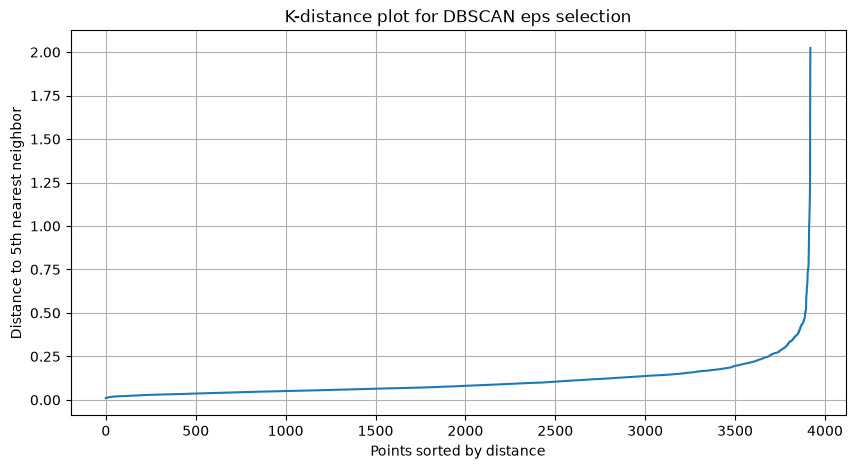

In [18]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

min_samples = 5  # rule of thumb: min_samples >= dimensions + 1 (we have 3 dims, so 4+ is reasonable; 5 is a common default)

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X1)
distances, indices = neighbors_fit.kneighbors(X1)

# Sort the distance to the k-th nearest neighbor for every point, ascending
k_distances = np.sort(distances[:, min_samples-1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.title("K-distance plot for DBSCAN eps selection")
plt.grid(True)
plt.show()

In [ ]:
dbscan_tuned = DBSCAN(eps=0.35, min_samples=5)
FS1['DBSCAN_label'] = dbscan_tuned.fit_predict(X1)

n_noise = (FS1['DBSCAN_label'] == -1).sum()
n_clusters = len(set(FS1['DBSCAN_label'])) - (1 if -1 in FS1['DBSCAN_label'].values else 0)
print(f"Clusters found: {n_clusters}")
print(f"Noise points (customer-level anomalies): {n_noise} ({n_noise/len(FS1)*100:.2f}%)")

print("\nCluster size breakdown:")
print(FS1['DBSCAN_label'].value_counts().sort_index())

Clusters found: 2
Noise points (customer-level anomalies): 51 (1.30%)

Cluster size breakdown:
DBSCAN_label
-1      51
 0    2525
 1    1344
Name: count, dtype: int64


In [20]:
eps_candidates = [0.25, 0.30, 0.35, 0.40, 0.45]

for eps_val in eps_candidates:
    db = DBSCAN(eps=eps_val, min_samples=5)
    labels = db.fit_predict(X1)
    n_noise = (labels == -1).sum()
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"eps={eps_val}: {n_clust} clusters, {n_noise} noise points ({n_noise/len(labels)*100:.2f}%)")

eps=0.25: 5 clusters, 148 noise points (3.78%)
eps=0.3: 4 clusters, 76 noise points (1.94%)
eps=0.35: 2 clusters, 51 noise points (1.30%)
eps=0.4: 1 clusters, 39 noise points (0.99%)
eps=0.45: 2 clusters, 25 noise points (0.64%)


## N1: Customer-Level Anomaly Detection via DBSCAN (Section 23)

**Method:** DBSCAN on FS1 (log1p + RobustScaler RFM features), min_samples=5 (rule of thumb: dimensions+1 for 3D data). `eps` selected via k-distance plot (knee at ~0.35), confirmed via sensitivity sweep:

| eps | Clusters | Noise points | % noise |
|---|---|---|---|
| 0.25 | 5 | 148 | 3.78% |
| 0.30 | 4 | 76 | 1.94% |
| 0.35 | 2 | 51 | 1.30% |
| 0.40 | 1 | 39 | 0.99% |
| 0.45 | 2 | 25 | 0.64% |

**Chosen: eps=0.35, min_samples=5** — matches the k-distance knee, gives a clean 2-cluster structure with a moderate, defensible noise rate (1.30%, within the typical 1-10% range for real customer anomaly detection). Note: cluster count is not strictly monotonic in eps (0.45 rebounds to 2 clusters) — a known, expected DBSCAN characteristic given local density variation, not a computation error.

**Result:** 51 customers (1.30%) flagged as behavioral noise — customers whose RFM profile doesn't fit densely near either main customer group.

In [22]:
customer_features_rfm = pd.read_csv("../data/processed/customer_features_rfm.csv")  # adjust extension if needed
customer_features_rfm['CustomerID'] = customer_features_rfm['CustomerID'].astype(str)
FS1['CustomerID'] = FS1['CustomerID'].astype(str)

FS1_dbscan_profiled = FS1.merge(
    customer_features_rfm[['CustomerID','Recency','Frequency','Monetary']],
    on='CustomerID', suffixes=('_scaled', '')
)

print(FS1_dbscan_profiled.shape)  # sanity check — should be close to 3920, not 0

(3920, 8)


In [23]:
noise_customers = FS1_dbscan_profiled[FS1_dbscan_profiled['DBSCAN_label'] == -1]
normal_customers = FS1_dbscan_profiled[FS1_dbscan_profiled['DBSCAN_label'] != -1]

print("=== Noise customers (n=51) — real RFM units ===")
print(noise_customers[['Recency','Frequency','Monetary']].describe())

print("\n=== Normal customers — real RFM units, for comparison ===")
print(normal_customers[['Recency','Frequency','Monetary']].describe())

=== Noise customers (n=51) — real RFM units ===
          Recency   Frequency       Monetary
count   51.000000   51.000000      51.000000
mean    59.490196   32.901961   38533.583529
std    104.738794   39.721659   50917.949007
min      0.000000    1.000000       3.750000
25%      2.000000    3.500000    2473.855000
50%      4.000000   17.000000   28754.110000
75%     41.000000   49.000000   55393.430000
max    372.000000  209.000000  259657.300000

=== Normal customers — real RFM units, for comparison ===
           Recency   Frequency      Monetary
count  3869.000000  3869.00000   3869.000000
mean     92.167227     3.86870   1374.983687
std      99.407421     4.59855   2277.016712
min       0.000000     1.00000     13.300000
25%      17.000000     1.00000    297.000000
50%      51.000000     2.00000    639.020000
75%     143.000000     5.00000   1532.200000
max     373.000000    47.00000  33643.080000


In [24]:
noise_customer_ids = set(noise_customers['CustomerID'].astype(str))

n0_flagged_customers = set(
    invoice_features[invoice_features['AnomalyFlag_N0_highconfidence']]['CustomerID'].astype(str)
)

overlap = noise_customer_ids & n0_flagged_customers
print(f"N1 noise customers: {len(noise_customer_ids)}")
print(f"N0-flagged customers: {len(n0_flagged_customers)}")
print(f"Overlap (flagged by BOTH methods): {len(overlap)}")
print(f"Overlap customer IDs: {overlap}")

N1 noise customers: 51
N0-flagged customers: 382
Overlap (flagged by BOTH methods): 32
Overlap customer IDs: {'16013', '14096', '16029', '13798', '13093', '17841', '15098', '17389', '12748', '16446', '14298', '13694', '14088', '15769', '16684', '17450', '16000', '16422', '15061', '17949', '12931', '16745', '14422', '15195', '17511', '13089', '14680', '13081', '12346', '15311', '18102', '15749'}


In [25]:
# Do the overlap customers look like our known likely-error cases, or just big genuine spenders?
overlap_profile = FS1_dbscan_profiled[FS1_dbscan_profiled['CustomerID'].isin(overlap)]
print(overlap_profile[['CustomerID','Recency','Frequency','Monetary']].sort_values('Monetary', ascending=False))

# Confirm: are our 2 known data-entry-error customers (12346, 16446) in this overlap?
print("\n12346 in overlap:", '12346' in overlap)
print("16446 in overlap:", '16446' in overlap)

     CustomerID  Recency  Frequency   Monetary
3783      18102        0         60  259657.30
3314      17450        8         46  194390.79
2598      16446        0          2  168472.50
3356      17511        2         31   91062.38
2294      16029       38         63   80850.84
0         12346      325          1   77183.60
2766      16684        4         28   66653.56
902       14096        4         17   65164.79
620       13694        3         50   65039.62
1771      15311        0         91   60632.75
191       13089        2         97   58762.08
3675      17949        1         45   58510.48
2109      15769        7         26   56252.72
1579      15061        3         48   54534.14
1044      14298        8         44   51527.30
897       14088       10         13   50491.81
2094      15749      235          3   44534.30
82        12931       21         15   42055.96
3593      17841        1        124   40519.84
1607      15098      182          3   39916.50
693       137

## N1: DBSCAN Customer-Level Anomaly Detection - Findings (Section 23)

**What N1 actually detects:** comparing noise customers (n=51) against normal customers shows noise points are overwhelmingly high-value, high-frequency customers (median Frequency 17 vs. 2; median Monetary £28,754 vs. £639) - not suspicious behavior, but statistical rarity. Being an excellent customer is uncommon enough in RFM-space that DBSCAN cannot place these customers in a dense neighborhood, so they're correctly labeled noise by the algorithm's definition, without implying anything is wrong with them.

**Cross-method overlap with N0:** 32 of 51 (62.7%) N1 noise customers also had a high-confidence N0-flagged invoice. Both confirmed data-entry-error customers (12346, 16446) fall in this overlap, as expected - their anomalous single invoices inflate their overall customer-level Monetary enough to also register as DBSCAN noise. However, manual inspection of the remaining 30 overlap customers shows most are simply large, consistent high-frequency spenders (e.g., customer 12748 with Frequency=209, the most active customer in the dataset) - not one-off spikes. 

**Conclusion:** N0 and N1 measure genuinely different things - N0 flags unusual *transactions*, N1 flags unusual *customers* (mostly high-value ones, by construction of what "rare" means in RFM-space). Their 62.7% overlap is real but should not be read as strong independent corroboration of suspicious activity; it mostly reflects that active, big-spending customers naturally have more invoices and therefore more opportunities to also trip invoice-level thresholds. The genuinely actionable overlap cases are the 2 already-confirmed data-entry errors (12346, 16446), plus 1-2 borderline cases (e.g., 16446-style high-value-low-frequency ratios) worth a light manual review, not the full 32-customer overlap set.

In [27]:
import os

os.makedirs("../results/tables", exist_ok=True)
invoice_features.to_csv("../results/tables/invoice_anomaly_flags_N0.csv", index=False)
FS1_dbscan_profiled.to_csv("../results/tables/customer_anomaly_flags_N1.csv", index=False)
print("Saved.")

Saved.
